In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import math
import yaml
from typing import Tuple, Any, Dict, List
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from src.utils import load_config, load_data, serialize_data, deserialize_data, get_project_root

In [40]:
def save_to_config(key: str, value: any, filename: str = "config.yaml"):
    """
    Menyimpan key dan value baru LANGSUNG ke file config.yaml
    tanpa merusak path yang sudah ada.
    """
    path_config = get_project_root() / "config" / filename
    
    with open(path_config, "r") as file:
        raw_config = yaml.safe_load(file) or {}
        
    raw_config[key] = value
    
    with open(path_config, "w") as file:
        yaml.dump(raw_config, file, default_flow_style=False, sort_keys=True)
        
    print(f"Berhasil menyimpan permanen: '{key}' ke {filename}")

In [41]:
config = load_config()

In [42]:
config

{'bin_cb_person_cred_hist_length': [-inf, 2.5, 4.5, 8.5, inf],
 'bin_loan_amnt': [-inf, 7500.0, 12500.0, 18000.0, 22000.0, inf],
 'bin_loan_int_rate': [-inf, 6.5, 9.5, 13, 14.5, 15.5, inf],
 'bin_loan_percent_income': [-inf, 0.1, 0.2, 0.3, 0.4, inf],
 'bin_person_age': [0, 23, 28, 100],
 'bin_person_emp_length': [-inf, 0.5, 1.5, 2.5, 4.5, 11.5, inf],
 'bin_person_income': [-inf, 35000.0, 60000.0, 80000.0, inf],
 'categorical_grouping': {'loan_grade': {'E': 'D', 'F': 'D', 'G': 'D'},
  'person_home_ownership': {'OTHER': 'RENT'}},
 'columns_cat': ['person_home_ownership',
  'loan_intent',
  'loan_grade',
  'cb_person_default_on_file'],
 'columns_num': ['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 'columns_predictors': ['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length',
  'person_home_ownershi

In [43]:
path_X_train_woe, path_y_train_woe = config["path_train_woe"]
path_X_valid_woe, path_y_valid_woe = config["path_valid_woe"]
path_X_test_woe, path_y_test_woe = config["path_test_woe"]

In [44]:
X_train_woe = deserialize_data(path_X_train_woe)
y_train_woe = deserialize_data(path_y_train_woe)

X_valid_woe = deserialize_data(path_X_valid_woe)
y_valid_woe = deserialize_data(path_y_valid_woe)

X_test_woe = deserialize_data(path_X_test_woe)
y_test_woe = deserialize_data(path_y_test_woe)

In [45]:
X_train_woe.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
29762,0.090555,0.041649,0.665664,-0.303031,-0.365185,0.357341,0.190565,0.234443,0.446517,0.216175,0.083654
2714,-0.000003,0.041649,-0.504023,0.193336,0.138291,0.920770,0.118896,0.803903,-0.016713,0.216175,-0.092537
50,-0.000003,0.412946,-0.504023,0.064756,-0.365185,-1.693926,-0.696881,0.234443,-2.032692,-0.781869,-0.033310
28458,0.090555,0.412946,-0.504023,-0.201729,0.294734,0.036821,0.118896,0.234443,0.446517,0.216175,0.051316
3674,-0.000003,-0.993186,-0.504023,-0.201729,0.460260,0.357341,0.190565,0.234443,-0.016713,0.216175,-0.033310


In [46]:
root = get_project_root()

In [47]:
df_iv = pd.read_csv(str(root/config["path_iv_summary"]))

In [48]:
df_iv

,Nama Fitur,Total Information Value,Kekuatan Fitur
0,loan_percent_income,0.919998,Potensi Leakage
1,loan_grade,0.823567,Potensi Leakage
2,loan_int_rate,0.653348,Potensi Leakage
3,person_income,0.447230,Kuat (sangat prediktif)
4,person_home_ownership,0.378106,Kuat (sangat prediktif)
5,cb_person_default_on_file,0.166691,Medium
6,loan_intent,0.096369,Lemah
7,loan_amnt,0.080200,Lemah
8,person_emp_length,0.053583,Lemah
9,person_age,0.005646,Gaguna (buang)


In [49]:
fitur_input = [
    "loan_percent_income",
    "loan_int_rate",
    "person_income",
    "person_home_ownership",
    "cb_person_default_on_file",
    "loan_intent"
]

X_pilihan = X_train_woe[fitur_input]

In [50]:
X_pilihan.head()

,loan_percent_income,loan_int_rate,person_income,person_home_ownership,cb_person_default_on_file,loan_intent
29762,0.446517,0.234443,0.041649,0.665664,0.216175,-0.365185
2714,-0.016713,0.803903,0.041649,-0.504023,0.216175,0.138291
50,-2.032692,0.234443,0.412946,-0.504023,-0.781869,-0.365185
28458,0.446517,0.234443,0.412946,-0.504023,0.216175,0.294734
3674,-0.016713,0.234443,-0.993186,-0.504023,0.216175,0.460260


In [51]:
y_train_woe.head()

29762    0
2714     0
50       1
28458    0
3674     1
Name: loan_status, dtype: int64

In [52]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [53]:
def calculate_vif(X):

    vif_data = pd.DataFrame()
    vif_data["Nama Fitur"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]   

    vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
    
    return vif_data

,Nama Fitur,VIF
0,loan_int_rate,1.306207
1,cb_person_default_on_file,1.278960
2,person_income,1.177607
3,loan_percent_income,1.128911
4,person_home_ownership,1.085782
5,loan_intent,1.005810


In [55]:
import statsmodels.api as sm

In [56]:
X_train_sm = sm.add_constant(X_pilihan)
X_valid_sm = sm.add_constant(X_valid_woe[fitur_input])
X_test_sm = sm.add_constant(X_test_woe[fitur_input])

In [57]:
X_train_sm.head()

,const,loan_percent_income,loan_int_rate,person_income,person_home_ownership,cb_person_default_on_file,loan_intent
29762,1.0,0.446517,0.234443,0.041649,0.665664,0.216175,-0.365185
2714,1.0,-0.016713,0.803903,0.041649,-0.504023,0.216175,0.138291
50,1.0,-2.032692,0.234443,0.412946,-0.504023,-0.781869,-0.365185
28458,1.0,0.446517,0.234443,0.412946,-0.504023,0.216175,0.294734
3674,1.0,-0.016713,0.234443,-0.993186,-0.504023,0.216175,0.460260


In [58]:
X_train_sm.shape

(25954, 7)

In [59]:
log_reg = sm.Logit(y_train_woe, X_train_sm).fit()

Optimization terminated successfully.
         Current function value: 0.343766
         Iterations 7


In [60]:
log_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                25954
Model:                          Logit   Df Residuals:                    25947
Method:                           MLE   Df Model:                            6
Date:                Tue, 10 Mar 2026   Pseudo R-squ.:                  0.3454
Time:                        22:23:57   Log-Likelihood:                -8922.1
converged:                       True   LL-Null:                       -13630.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.3406      0.020    -67.043      0.000      -1.380      -1.301
loan_percent_income          -1.0603      0.020    -51.995      0.000      -1.100      -1.020
loan_int_rate                -1.1723      0.026    -44.396      0.000      -1.224      -1.121
person_income                -0.6876      0.030    -23.164      0.000      -0.746      -0.629
person_home_ownership        -0.9307      0.032    -28.758      0.000      -0.994      -0.867
cb_person_default_on_file    -0.2084      0.048     -4.319      0.000      -0.303      -0.114
loan_intent                  -1.3905      0.063    -22.096      0.000      -1.514      -1.267
=============================================================================================
"""

In [61]:
from sklearn.metrics import roc_auc_score

In [62]:
y_train_pred_proba = log_reg.predict(X_train_sm)
y_valid_pred_proba = log_reg.predict(X_valid_sm)

In [63]:
def evaluate_credit_model(y_true, y_pred_proba, dataset_name="Dataset"):
    
    auc = roc_auc_score(y_true, y_pred_proba)

    gini = (2 * auc) - 1
    
    df = pd.DataFrame({"target": y_true, "proba": y_pred_proba})
    df = df.sort_values(by="proba", ascending=False).reset_index(drop=True)
    
    df["kumulatif_galbay"] = df["target"].cumsum() / df["target"].sum()
    df["kumulatif_cakep"] = (1 - df["target"]).cumsum() / (1 - df["target"]).sum()
    
    ks_stat = np.max(np.abs(df["kumulatif_galbay"] - df["kumulatif_cakep"]))
    
    print(f"=== Evaluasi {dataset_name} ===")
    print(f"AUC  : {auc:.4f} (Target industri > 0.70)")
    print(f"Gini : {gini:.4f} (Target industri > 0.40)")
    print(f"KS   : {ks_stat:.4f} (Target industri > 0.30)\n")

In [64]:
evaluate_credit_model(y_train_woe, y_train_pred_proba, "Data Train")
evaluate_credit_model(y_valid_woe, y_valid_pred_proba, "Data Validasi")

=== Evaluasi Data Train ===
AUC  : 0.8650 (Target industri > 0.70)
Gini : 0.7299 (Target industri > 0.40)
KS   : 0.5766 (Target industri > 0.30)

=== Evaluasi Data Validasi ===
AUC  : 0.8678 (Target industri > 0.70)
Gini : 0.7356 (Target industri > 0.40)
KS   : 0.5896 (Target industri > 0.30)



In [65]:
def plot_credit_scoring_metrics(y_true, y_pred_proba, title_prefix="Dataset"):

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Visualisasi Evaluasi Model: {title_prefix}", fontsize=16, fontweight="bold", y=1.05)

    #ROC CURVE & AUC/GINI
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = (2 * auc) - 1
    
    axes[0].plot(fpr, tpr, label=f'ROC Curve\n(AUC = {auc:.4f}, Gini = {gini:.4f})', color='blue', linewidth=2)
    axes[0].plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)
    axes[0].set_title('ROC Curve', fontsize=12)
    axes[0].set_xlabel('False Positive Rate (FPR)')
    axes[0].set_ylabel('True Positive Rate (TPR)')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    #KS PLOT
    df = pd.DataFrame({'target': y_true, 'proba': y_pred_proba})
    df = df.sort_values(by='proba', ascending=False).reset_index(drop=True)
    df['kumulatif_galbay'] = df['target'].cumsum() / df['target'].sum()
    df['kumulatif_cakep'] = (1 - df['target']).cumsum() / (1 - df['target']).sum()
    df['persentase_populasi'] = (df.index + 1) / len(df)
    
    ks_stat = np.max(np.abs(df['kumulatif_galbay'] - df['kumulatif_cakep']))
    ks_idx = np.argmax(np.abs(df['kumulatif_galbay'] - df['kumulatif_cakep']))
    ks_pop_pct = df['persentase_populasi'][ks_idx]
    
    axes[1].plot(df['persentase_populasi'], df['kumulatif_galbay'], label='Kumulatif Galbay', color='red', linewidth=2)
    axes[1].plot(df['persentase_populasi'], df['kumulatif_cakep'], label='Kumulatif Cakep', color='green', linewidth=2)
    
    # Gambar garis vertikal penanda KS
    axes[1].axvline(ks_pop_pct, color='black', linestyle='--', 
                    label=f'KS Stat = {ks_stat:.4f}\n@ {ks_pop_pct*100:.1f}% Populasi')
    
    axes[1].set_title('Kolmogorov-Smirnov (KS) Plot', fontsize=12)
    axes[1].set_xlabel('Persentase Populasi')
    axes[1].set_ylabel('Persentase Kumulatif')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)

    #Confusion Matrix Threeshold 0.5
    y_pred_class = (y_pred_proba >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred_class)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2],
                xticklabels=['Cakep (0)', 'Galbay (1)'], 
                yticklabels=['Cakep (0)', 'Galbay (1)'],
                cbar=False, annot_kws={"size": 14})
    axes[2].set_title('Confusion Matrix (Threshold 0.5)', fontsize=12)
    axes[2].set_xlabel('Prediksi Model')
    axes[2].set_ylabel('Aktual (Data Asli)')

    plt.tight_layout()
    plt.show()

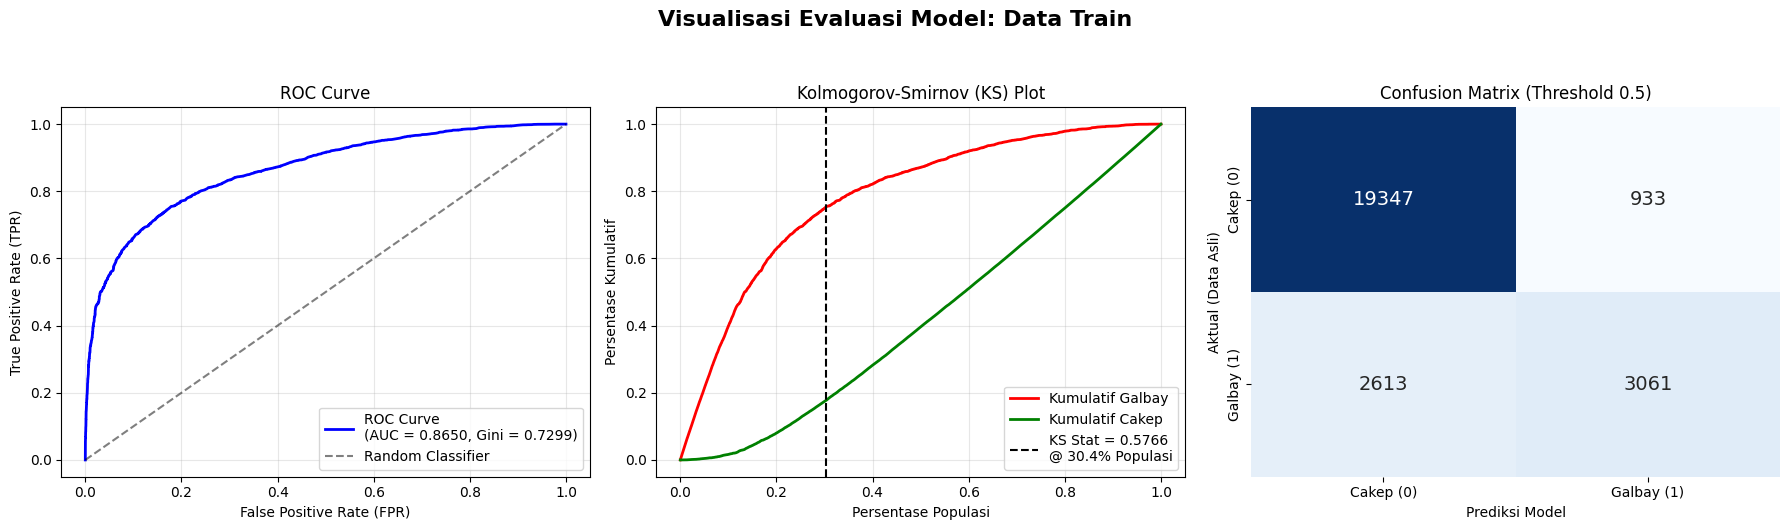

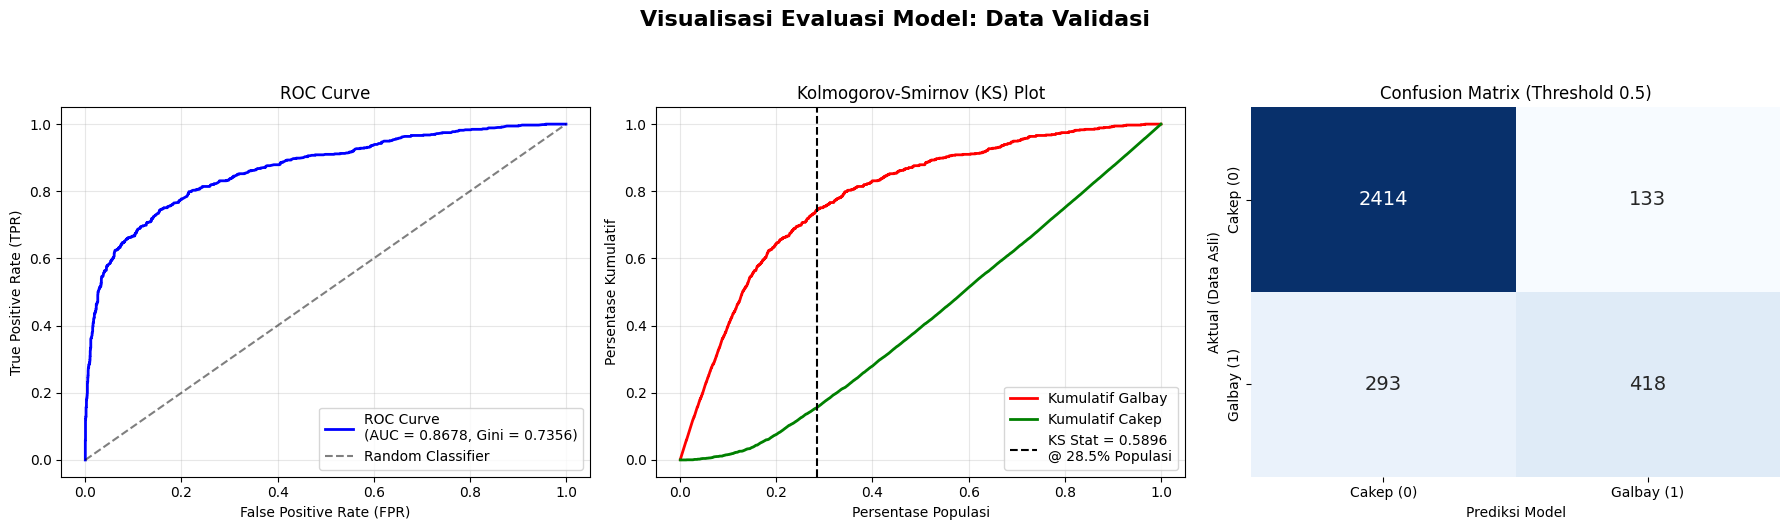

In [66]:
plot_credit_scoring_metrics(y_train_woe, y_train_pred_proba, "Data Train")
plot_credit_scoring_metrics(y_valid_woe, y_valid_pred_proba, "Data Validasi")

In [67]:
import pickle

In [68]:
print("=== MEMBUAT CREDIT SCORECARD ===")

#Target score standard FICO
target_score = 600
target_odds = 50   #dari skor 600 kita ingin 50 Nasabah baik di antara 1 yang galbay atau 50:1
pdo = 20           # Tambah 20 poin = Odds membaik 2x lipat

#Kalkulasi Factor dan Offset
factor = pdo / np.log(2)
offset = target_score - (factor * np.log(target_odds))
print(f"Berdasarkan rumus, Factor: {factor:.2f} | Offset: {offset:.2f}")

#Ekstrak Koefisien (Beta) dan Intercept (Alpha) dari Model
alpha = log_reg.params['const']
n_features = len(fitur_input)

#Load kembali WoE Mappings
path_woe_mappings = config.get("path_woe_mappings", "models/woe_mappings.pkl")
with open(str(root/path_woe_mappings), 'rb') as f:
    woe_mappings = pickle.load(f)

#Iterasi dan Hitung Poin per Kategori
scorecard_list = []

for col in fitur_input:
    beta = log_reg.params[col]
    woe_dict = woe_mappings[col]
    
    for kategori, woe_value in woe_dict.items():
        #Rumus Poin: (Offset / n) - Factor * (alpha / n + beta * WoE)
        #Tanda minus karena model Logit kita memprediksi risiko Galbay (1)
        poin = (offset / n_features) - factor * ((alpha / n_features) + (beta * woe_value))
        
        scorecard_list.append({
            "Fitur": col,
            "Kategori / Bin": kategori,
            "WoE": woe_value,
            "Koefisien (Beta)": beta,
            "Poin Scorecard": round(poin)  
        })

df_scorecard = pd.DataFrame(scorecard_list)

print("\n=== TABEL FINAL CREDIT SCORECARD ===")
display_scorecard = df_scorecard[['Fitur', 'Kategori / Bin', 'Poin Scorecard']]
display(display_scorecard.groupby(['Fitur', 'Kategori / Bin']).mean())

=== MEMBUAT CREDIT SCORECARD ===
Berdasarkan rumus, Factor: 28.85 | Offset: 487.12

=== TABEL FINAL CREDIT SCORECARD ===


Poin Scorecard
Fitur                     Kategori / Bin                    
cb_person_default_on_file N                             89.0
                          Y                             83.0
loan_int_rate             (-inf, 6.5]                  135.0
                          (13.0, 14.5]                  79.0
                          (14.5, 15.5]                  49.0
                          (15.5, inf]                   30.0
                          (6.5, 9.5]                   115.0
                          (9.5, 13.0]                   96.0
loan_intent               DEBTCONSOLIDATION             73.0
                          EDUCATION                     99.0
                          HOMEIMPROVEMENT               77.0
                          MEDICAL                       77.0
                          PERSONAL                      93.0
                          VENTURE                      106.0
loan_percent_income       (-inf, 0.1]                  110.0
                          (0.1, 0.2]                   101.0
                          (0.2, 0.3]                    87.0
                          (0.3, 0.4]                    25.0
                          (0.4, inf]                    15.0
person_home_ownership     MORTGAGE                     106.0
                          OWN                          121.0
                          RENT                          74.0
person_income             (-inf, 35000.0]               68.0
                          (35000.0, 60000.0]            88.0
                          (60000.0, 80000.0]            96.0
                          (80000.0, inf]               107.0

In [69]:
df_scorecard

,Fitur,Kategori / Bin,WoE,Koefisien (Beta),Poin Scorecard
0,loan_percent_income,"(-inf, 0.1]",0.747081,-1.060250,110
1,loan_percent_income,"(0.1, 0.2]",0.446517,-1.060250,101
2,loan_percent_income,"(0.2, 0.3]",-0.016713,-1.060250,87
3,loan_percent_income,"(0.3, 0.4]",-2.032692,-1.060250,25
4,loan_percent_income,"(0.4, inf]",-2.382951,-1.060250,15
5,loan_int_rate,"(-inf, 6.5]",1.406246,-1.172261,135
6,loan_int_rate,"(13.0, 14.5]",-0.240726,-1.172261,79
7,loan_int_rate,"(14.5, 15.5]",-1.133735,-1.172261,49
8,loan_int_rate,"(15.5, inf]",-1.714556,-1.172261,30
9,loan_int_rate,"(6.5, 9.5]",0.803903,-1.172261,115


In [70]:
df_scorecard.to_csv("scorecard_points.csv", index=False)

In [71]:
PATH_SCORECARD_DICT = "models/api_scorecard_dict.pkl"

In [72]:
save_to_config(
    key="path_scorecard_dict",
    value=PATH_SCORECARD_DICT
)

Berhasil menyimpan permanen: 'path_scorecard_dict' ke config.yaml


In [73]:
config = load_config()

In [74]:
api_scorecard_dict = {}
for fitur in df_scorecard["Fitur"].unique():
    df_subset = df_scorecard[df_scorecard["Fitur"] == fitur]
    api_scorecard_dict[fitur] = dict(zip(df_subset["Kategori / Bin"], df_subset["Poin Scorecard"]))

In [75]:
api_scorecard_dict

{'loan_percent_income': {'(-inf, 0.1]': 110,
  '(0.1, 0.2]': 101,
  '(0.2, 0.3]': 87,
  '(0.3, 0.4]': 25,
  '(0.4, inf]': 15},
 'loan_int_rate': {'(-inf, 6.5]': 135,
  '(13.0, 14.5]': 79,
  '(14.5, 15.5]': 49,
  '(15.5, inf]': 30,
  '(6.5, 9.5]': 115,
  '(9.5, 13.0]': 96},
 'person_income': {'(-inf, 35000.0]': 68,
  '(35000.0, 60000.0]': 88,
  '(60000.0, 80000.0]': 96,
  '(80000.0, inf]': 107},
 'person_home_ownership': {'MORTGAGE': 106, 'OWN': 121, 'RENT': 74},
 'cb_person_default_on_file': {'N': 89, 'Y': 83},
 'loan_intent': {'DEBTCONSOLIDATION': 73,
  'EDUCATION': 99,
  'HOMEIMPROVEMENT': 77,
  'MEDICAL': 77,
  'PERSONAL': 93,
  'VENTURE': 106}}

In [76]:
serialize_data(api_scorecard_dict, config["path_scorecard_dict"])

In [77]:
print("=== MEMBUAT TABEL STRATEGI CUT-OFF BISNIS ===")

#Ubah probabilitas data validasi menjadi Skor Ratusan
#Rumus matematis Skor: Offset - Factor * ln(Odds Galbay)
eps = 1e-10 # Pelindung agar tidak error membagi 0
odds_galbay = y_valid_pred_proba / (1 - y_valid_pred_proba + eps)
skor_validasi = offset - (factor * np.log(odds_galbay + eps))

#Gabungkan Skor dengan data Aktual (Galbay atau tidak)
df_eval = pd.DataFrame({
    'Skor_Nasabah': skor_validasi,
    'Aktual_Galbay': y_valid_woe.values
})

total_nasabah = len(df_eval)

#Buat simulasi batas Cut-off dari skor 400 sampai 750
cutoff_list = np.arange(400, 775, 25)
strategy_table = []

for cutoff in cutoff_list:
    #Aturan: Nasabah yang disetujui (Approve) adalah yang skornya >= Cut-off
    df_approved = df_eval[df_eval['Skor_Nasabah'] >= cutoff]
    
    jml_approved = len(df_approved)
    approval_rate = jml_approved / total_nasabah
    
    #Menghitung berapa persen yang gagal bayar dari yang disetujui saja
    if jml_approved > 0:
        jml_galbay_terloloskan = df_approved['Aktual_Galbay'].sum()
        bad_rate = jml_galbay_terloloskan / jml_approved
    else:
        bad_rate = 0
        
    strategy_table.append({
        'Batas Minimal Skor (Cut-off)': cutoff,
        'Nasabah Disetujui': jml_approved,
        'Approval Rate (%)': round(approval_rate * 100, 2),
        'Bad Rate / NPL (%)': round(bad_rate * 100, 2)
    })
    
df_strategy = pd.DataFrame(strategy_table)
display(df_strategy)

=== MEMBUAT TABEL STRATEGI CUT-OFF BISNIS ===


,Batas Minimal Skor (Cut-off),Nasabah Disetujui,Approval Rate (%),Bad Rate / NPL (%)
0,400,3216,98.71,20.80
1,425,3146,96.56,19.17
2,450,3013,92.48,16.30
3,475,2823,86.65,12.36
4,500,2591,79.53,9.65
5,525,2194,67.34,7.20
6,550,1582,48.56,5.06
7,575,948,29.10,3.48
8,600,392,12.03,2.04
9,625,96,2.95,0.00
